<a href="https://colab.research.google.com/github/SHaruto0/CSCI-4170-Project-in-AI-and-ML/blob/main/HW3/Haruto_Suzuki_HW3_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Analysis on the PDF

# Import Libraries

In [20]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from itertools import product
import pandas as pd

import pickle

### Data from
https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset/data

Download to your computer using download.py

Unzip Data

In [42]:
!unzip /content/Rice_Image_Dataset.zip

Archive:  /content/Rice_Image_Dataset.zip
replace Rice_Image_Dataset/Arborio/Arborio (1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## Visualize Original Images and Processed Image

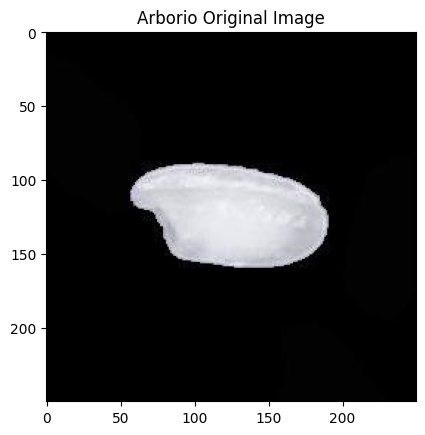

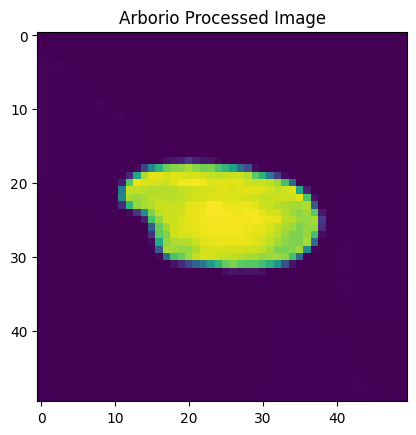

In [22]:
path = "/content/Rice_Image_Dataset/Arborio/Arborio (1).jpg"
image = Image.open(path)
plt.title("Arborio Original Image")
plt.imshow(image)
plt.show()
plt.close()

plt.title("Arborio Processed Image")
gray = image.convert("L") # Gray Scale
resized = gray.resize((50, 50))  # To reduce input size. 50*50 = 2500
plt.imshow(resized)
plt.show()

# Dataset Class

In [23]:
class Dataset:
  def __init__(self, dir_path, num_images):
    self.dir_path = dir_path
    self.num_images = num_images
    self.data = []
    self.labels = []

  # Load all the images and returns the image and the label as an np.array
  def load(self, seed=42):
    np.random.seed(seed)

    dirs = os.listdir(self.dir_path)
    for dir in dirs:
      dir_path = os.path.join(self.dir_path, dir)

      if os.path.isdir(dir_path):
        images = os.listdir(dir_path)
        images = np.random.choice(images, self.num_images, replace=False)
        for i in range(self.num_images):
          image_path = os.path.join(dir_path, images[i])
          data, label = self.preprocess(image_path)
          self.data.append(data)
          self.labels.append(label)

    self.data = np.array(self.data)
    self.labels = np.array(self.labels)
    self.labels = self.onehot(self.labels)
    return self.data, self.labels

  # Resizes the image and gray scale it as well. Also returns the label
  def preprocess(self, path):
    image = Image.open(path)
    gray = image.convert("L") # Gray Scale
    resized = gray.resize((50, 50))  # To reduce input size. 50*50 = 2500
    data = np.array(resized)
    data = data.flatten() / 255.0

    if "arborio" in path.lower():
      label = 0
    elif "basmati" in path.lower():
      label = 1
    elif "ipsala" in path.lower():
      label = 2
    elif "jasmine" in path.lower():
      label = 3
    elif "karacadag" in path.lower():
      label = 4

    return data, label

  # Creates One hot Encoding given an array of labels
  def onehot(self, labels):
    onehot = np.zeros((len(labels), 5))
    onehot[np.arange(len(labels)), labels] = 1
    return onehot

# Neural Network Class

In [24]:
class NeuralNetwork:
  def __init__(self, input_size, num_hidden_layer, hidden_size, output_size, gradient_type="batch", epochs=10, batch_size=64, lr=1e-4, seed=42):
    np.random.seed(seed)

    self.input_size = input_size
    self.num_hidden_layer = num_hidden_layer
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.epochs = epochs
    self.batch_size = batch_size
    self.lr = lr
    self.gradient_type = gradient_type

    self.weights = []
    self.biases = []

    self.loss_history = []
    self.class_accuracy_history = []

    # Creating Layers
    if num_hidden_layer == 0:
      self.weights.append(np.random.randn(input_size, output_size))
      self.biases.append(np.random.randn(1, output_size))
    else:
      for i in range(num_hidden_layer+1):
        if i == 0:
          self.weights.append(np.random.randn(input_size, hidden_size))
          self.biases.append(np.random.randn(1, hidden_size))
        elif i == num_hidden_layer:
          self.weights.append(np.random.randn(hidden_size, output_size))
          self.biases.append(np.random.randn(1, output_size))
        else:
          self.weights.append(np.random.randn(hidden_size, hidden_size))
          self.biases.append(np.random.randn(1, hidden_size))

  def softmax(self, X):
    X = X - np.max(X, axis=1, keepdims=True)
    sum = np.sum(np.exp(X), axis=1, keepdims=True)
    return np.exp(X) / sum

  def relu(self, X):
    return np.maximum(0, X)

  def loss(self, y_pred, y_true):
    # Cross Entropy Loss
    # This eps is to prevent log(0) which is undefined
    eps = 1e-10
    return -np.sum(y_true * np.log(y_pred + eps))

  def gradient(self, y_pred, y_true, A, Z):
    grads_W = [None] * len(self.weights)
    grads_b = [None] * len(self.biases)

    # Output layer gradient (softmax + cross-entropy)
    grad_y_hat = y_pred - y_true
    L = self.num_hidden_layer

    batch_size = y_pred.shape[0]

    grads_W[L] = (A[L].T @ grad_y_hat) / batch_size
    grads_b[L] = np.sum(grad_y_hat, axis=0, keepdims=True) / batch_size

    # Backprop through hidden layers
    for l in reversed(range(L)):
        dA = grad_y_hat @ self.weights[l+1].T
        dZ = dA * (Z[l] > 0)  # ReLU derivative
        grad_y_hat = dZ

        grads_W[l] = (A[l].T @ grad_y_hat) / batch_size
        grads_b[l] = np.sum(grad_y_hat, axis=0, keepdims=True) / batch_size

    return grads_W, grads_b

  def forward(self, X):
    A = [X] # Store layers after activation
    Z = []  # Store layers before activation

    for i in range(self.num_hidden_layer):
        Z_i = np.dot(A[-1], self.weights[i]) + self.biases[i]
        A_i = self.relu(Z_i)
        Z.append(Z_i)
        A.append(A_i)

    # Output layer (no ReLU, just softmax)
    Z_out = np.dot(A[-1], self.weights[-1]) + self.biases[-1]
    y_pred = self.softmax(Z_out)
    Z.append(Z_out)
    A.append(y_pred)

    return y_pred, A, Z

  def predict(self, X):
    y_pred, _, _ = self.forward(X)
    predictions = np.argmax(y_pred, axis=1)
    return predictions

  def evaluate(self, y, y_pred):
    accuracy = np.mean(y_pred == y)
    return accuracy

  def per_class_accuracy(self, y_true, y_pred, num_classes):
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)
    correct = np.zeros(num_classes)
    total = np.zeros(num_classes)

    for i in range(len(y_true_labels)):
        label = y_true_labels[i]
        total[label] += 1
        if y_pred_labels[i] == label:
            correct[label] += 1

    return correct / total

  def batch_gradient(self, X, y):
    for epoch in range(self.epochs):
        y_pred, A, Z = self.forward(X)
        loss = self.loss(y_pred, y) / len(X)
        grads_W, grads_b = self.gradient(y_pred, y, A, Z)

        # Gradient descent update
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * grads_W[i]
            self.biases[i] -= self.lr * grads_b[i]

        accuracy = self.evaluate(y, y_pred)
        self.loss_history.append(loss)

        class_acc = self.per_class_accuracy(y, y_pred, self.output_size)
        self.class_accuracy_history.append(class_acc)

        print(f"Epoch [{epoch+1}/{self.epochs}]: Accuracy: {accuracy:.4f},  Loss: {loss:.4f}")

  def mini_batch(self, X, y):
    for epoch in range(self.epochs):
        indices = np.arange(X.shape[0])
        np.random.shuffle(indices)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        total_loss = 0
        correct = 0
        total = 0
        epoch_class_acc = np.zeros(self.output_size)
        class_counts = np.zeros(self.output_size)

        for j in range(0, X.shape[0], self.batch_size):
            X_batch = X_shuffled[j:j+self.batch_size]
            y_batch = y_shuffled[j:j+self.batch_size]

            y_pred, A, Z = self.forward(X_batch)
            loss = self.loss(y_pred, y_batch) / len(X_batch)
            grads_W, grads_b = self.gradient(y_pred, y_batch, A, Z)

            # Update weights
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * grads_W[i]
                self.biases[i] -= self.lr * grads_b[i]

            total_loss += loss
            total += len(y_batch)
            correct += np.sum(np.argmax(y_pred, axis=1) == np.argmax(y_batch, axis=1))

            class_acc = self.per_class_accuracy(y_batch, y_pred, self.output_size)
            for c in range(self.output_size):
                if not np.isnan(class_acc[c]):
                    epoch_class_acc[c] += class_acc[c]
                    class_counts[c] += 1

        avg_loss = total_loss / (X.shape[0] // self.batch_size)
        accuracy = correct / total
        avg_class_acc = epoch_class_acc / np.maximum(class_counts, 1)

        self.loss_history.append(avg_loss)
        self.class_accuracy_history.append(avg_class_acc)

        print(f"Epoch [{epoch+1}/{self.epochs}]: Accuracy: {accuracy:.4f}, Loss: {avg_loss:.4f}")


  def train(self, X, y):
    if self.gradient_type == "batch":
      self.batch_gradient(X, y)
    elif self.gradient_type == "mini-batch":
      self.mini_batch(X, y)

  def val(self, X, y):
    y_pred, _, _ = self.forward(X)
    loss = self.loss(y_pred, y) / len(X)
    accuracy = self.evaluate(y, y_pred)
    class_acc = self.per_class_accuracy(y, y_pred, self.output_size)

    print(f"Validation Accuracy: {accuracy:.4f},  Loss: {loss:.4f}")
    print("Per-class validation accuracy:")
    for i, acc in enumerate(class_acc):
        print(f"  Class {i}: {acc:.4f}")

  def plot(self, path_loss="loss.png", path_acc="acc.png"):
    plt.plot(self.loss_history)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.title("Loss vs Epochs")
    plt.savefig(path_loss)
    plt.show()
    plt.clf()

    class_acc = np.array(self.class_accuracy_history)
    for i in range(self.output_size):
        plt.plot(class_acc[:, i], label=f"Class {i}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Per-Class Accuracy over Training")
    plt.legend()
    plt.grid(True)
    plt.savefig(path_acc)
    plt.show()
    plt.clf()

  def save(self, filename="model.pkl"):
    with open(filename, "wb") as f:
        pickle.dump(self, f)

## Load Data

Load two sets of data. Since there are 15,000 samples for each class, so I will be randomly selecting 2,000 samples from each class with a total of 10,000 samples. Since there are plenty of data, I will be sampling 10,000 samples for training and another 10,000 samples for validation.

In [25]:
train_data = Dataset("/content/Rice_Image_Dataset", 2000)
train_images, train_labels = train_data.load(42)

print(train_images.shape)
print(train_labels.shape)

(10000, 2500)
(10000, 5)


In [26]:
val_data = Dataset("/content/Rice_Image_Dataset", 2000)
val_images, val_labels = val_data.load(43)

## Batch Gradient Descent

In [27]:
model = NeuralNetwork(
    input_size=2500,
    num_hidden_layer=5,
    hidden_size=100,
    output_size=5,
    gradient_type="batch",
    epochs=100,
    lr=1e-5
    )

start_time = time.time()
model.train(train_images, train_labels)
print(f"Training time: {time.time() - start_time} seconds")

Epoch [1/100]: Accuracy: 0.6827,  Loss: 18.2549
Epoch [2/100]: Accuracy: 0.6702,  Loss: 18.9249
Epoch [3/100]: Accuracy: 0.6804,  Loss: 18.3838
Epoch [4/100]: Accuracy: 0.6854,  Loss: 18.0684
Epoch [5/100]: Accuracy: 0.6925,  Loss: 17.6516
Epoch [6/100]: Accuracy: 0.7204,  Loss: 15.9574
Epoch [7/100]: Accuracy: 0.7446,  Loss: 14.4988
Epoch [8/100]: Accuracy: 0.7570,  Loss: 13.7626
Epoch [9/100]: Accuracy: 0.7617,  Loss: 13.5015
Epoch [10/100]: Accuracy: 0.7705,  Loss: 13.0094
Epoch [11/100]: Accuracy: 0.7746,  Loss: 12.7023
Epoch [12/100]: Accuracy: 0.7820,  Loss: 12.3028
Epoch [13/100]: Accuracy: 0.7874,  Loss: 11.9956
Epoch [14/100]: Accuracy: 0.7943,  Loss: 11.6102
Epoch [15/100]: Accuracy: 0.7995,  Loss: 11.2769
Epoch [16/100]: Accuracy: 0.8058,  Loss: 10.8973
Epoch [17/100]: Accuracy: 0.8109,  Loss: 10.6011
Epoch [18/100]: Accuracy: 0.8153,  Loss: 10.3714
Epoch [19/100]: Accuracy: 0.8192,  Loss: 10.1240
Epoch [20/100]: Accuracy: 0.8233,  Loss: 9.8906
Epoch [21/100]: Accuracy: 0.82

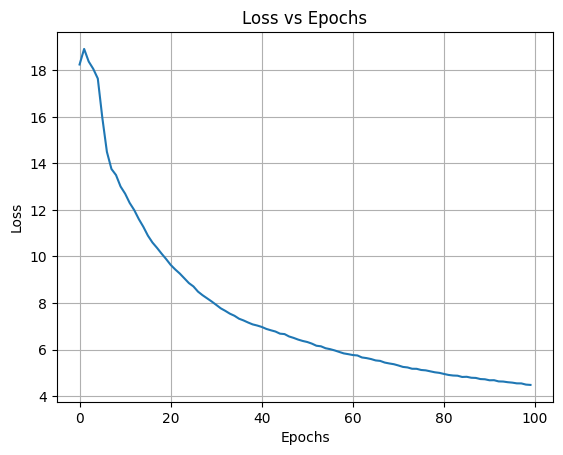

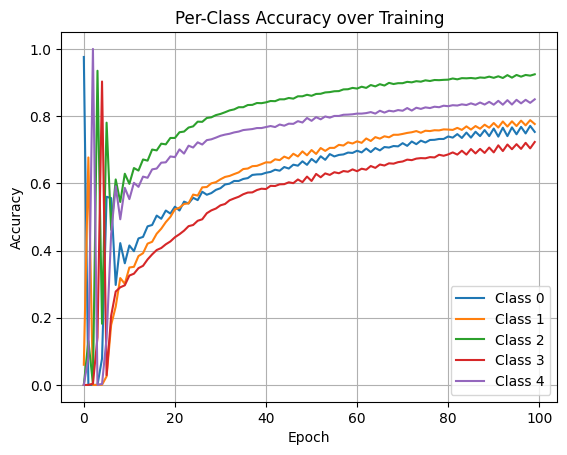

<Figure size 640x480 with 0 Axes>

In [28]:
model.plot()
model.save()

In [29]:
model.val(val_images, val_labels)

Validation Accuracy: 0.9133,  Loss: 4.7915
Per-class validation accuracy:
  Class 0: 0.7475
  Class 1: 0.7765
  Class 2: 0.9145
  Class 3: 0.6890
  Class 4: 0.8305


## Mini-Batch Gradient Descent

In [30]:
model = NeuralNetwork(
    input_size=2500,
    num_hidden_layer=5,
    hidden_size=100,
    output_size=5,
    gradient_type="mini-batch",
    epochs=30,
    lr=1e-5
    )

start_time = time.time()
model.train(train_images, train_labels)
print(f"Training time: {time.time() - start_time} seconds")

Epoch [1/30]: Accuracy: 0.7190, Loss: 6.4915
Epoch [2/30]: Accuracy: 0.8589, Loss: 3.2508
Epoch [3/30]: Accuracy: 0.8936, Loss: 2.4649
Epoch [4/30]: Accuracy: 0.9090, Loss: 2.0962
Epoch [5/30]: Accuracy: 0.9196, Loss: 1.8661


/tmp/ipython-input-24-3360109775.py:113: RuntimeWarning: invalid value encountered in divide
  return correct / total


Epoch [6/30]: Accuracy: 0.9277, Loss: 1.6672
Epoch [7/30]: Accuracy: 0.9314, Loss: 1.5829
Epoch [8/30]: Accuracy: 0.9370, Loss: 1.4520
Epoch [9/30]: Accuracy: 0.9399, Loss: 1.3876
Epoch [10/30]: Accuracy: 0.9422, Loss: 1.3330
Epoch [11/30]: Accuracy: 0.9496, Loss: 1.1598
Epoch [12/30]: Accuracy: 0.9500, Loss: 1.1546
Epoch [13/30]: Accuracy: 0.9525, Loss: 1.0985
Epoch [14/30]: Accuracy: 0.9523, Loss: 1.1053
Epoch [15/30]: Accuracy: 0.9557, Loss: 1.0292
Epoch [16/30]: Accuracy: 0.9598, Loss: 0.9391
Epoch [17/30]: Accuracy: 0.9582, Loss: 0.9757
Epoch [18/30]: Accuracy: 0.9603, Loss: 0.9137
Epoch [19/30]: Accuracy: 0.9644, Loss: 0.8181
Epoch [20/30]: Accuracy: 0.9642, Loss: 0.8234
Epoch [21/30]: Accuracy: 0.9655, Loss: 0.7984
Epoch [22/30]: Accuracy: 0.9692, Loss: 0.7195
Epoch [23/30]: Accuracy: 0.9662, Loss: 0.7819
Epoch [24/30]: Accuracy: 0.9719, Loss: 0.6411
Epoch [25/30]: Accuracy: 0.9740, Loss: 0.5977
Epoch [26/30]: Accuracy: 0.9739, Loss: 0.5984
Epoch [27/30]: Accuracy: 0.9738, Loss:

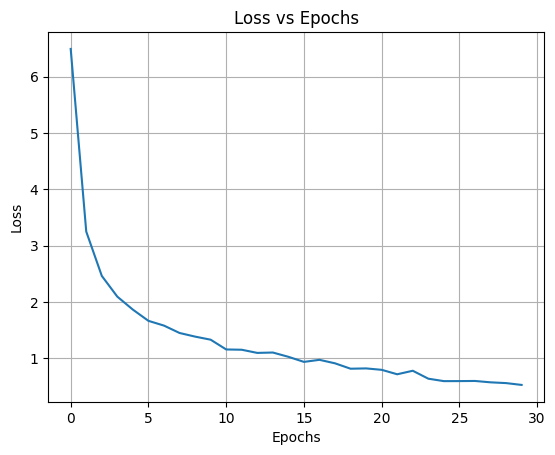

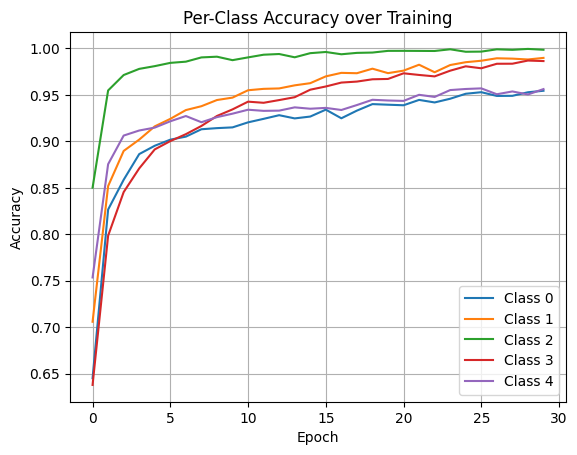

<Figure size 640x480 with 0 Axes>

In [31]:
model.plot()
model.save()

In [32]:
model.val(val_images, val_labels)

Validation Accuracy: 0.9708,  Loss: 1.5416
Per-class validation accuracy:
  Class 0: 0.9155
  Class 1: 0.9115
  Class 2: 0.9885
  Class 3: 0.9085
  Class 4: 0.9405


# Part 2: PyTorch

# Import Libraries

In [33]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

In [34]:
class Network(nn.Module):
    def __init__(self, input_size, num_hidden_layer, hidden_size, output_size, lr=1e-4, seed=42):
        super().__init__()
        torch.manual_seed(seed)
        np.random.seed(seed)

        self.lr = lr
        self.loss_history = []
        self.class_accuracy_history = []

        layers = []

        if num_hidden_layer == 0:
            layers.append(nn.Linear(input_size, output_size))
        else:
            for i in range(num_hidden_layer + 1):
                if i == 0:
                    layers.append(nn.Linear(input_size, hidden_size))
                    layers.append(nn.ReLU())
                elif i == num_hidden_layer:
                    layers.append(nn.Linear(hidden_size, output_size))
                else:
                    layers.append(nn.Linear(hidden_size, hidden_size))
                    layers.append(nn.ReLU())

        self.linear = nn.Sequential(*layers)
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.linear.parameters(), lr=self.lr)

    def forward(self, x):
        return self.linear(x)

    def per_class_accuracy(self, y_true, y_pred, num_classes):
        acc = []
        for cls in range(num_classes):
            cls_mask = (y_true == cls)
            if cls_mask.sum() == 0:
                acc.append(float('nan'))
            else:
                cls_correct = (y_pred[cls_mask] == y_true[cls_mask]).float().sum()
                acc.append((cls_correct / cls_mask.sum()).item())
        return acc

    def plot_loss(self):
        plt.plot(self.loss_history)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Loss Over Epochs")
        plt.grid(True)
        plt.savefig("loss.png")
        plt.show()

    def plot_class_accuracy(self):
        class_acc = np.array(self.class_accuracy_history)
        for i in range(class_acc.shape[1]):
            plt.plot(class_acc[:, i], label=f"Class {i}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Per-Class Accuracy")
        plt.legend()
        plt.grid(True)
        plt.savefig("acc.png")
        plt.show()

In [35]:
def train(model, data, labels, epochs=50):
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    model.train()
    num_classes = 5

    for epoch in range(epochs):
        model.optimizer.zero_grad()
        y_pred = model(data)
        loss = model.loss_fn(y_pred, labels)
        loss.backward()
        model.optimizer.step()

        preds = y_pred.argmax(dim=1)
        accuracy = (preds == labels).float().mean().item()
        class_acc = model.per_class_accuracy(labels, preds, num_classes)

        model.loss_history.append(loss.item())
        model.class_accuracy_history.append(class_acc)

        print(f"Epoch [{epoch+1}/{epochs}]: Accuracy: {accuracy:.4f},  Loss: {loss.item():.4f}")


def validate(model, data, labels):
    model.eval()
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    with torch.no_grad():
        y_pred = model(data)
        loss = model.loss_fn(y_pred, labels)
        preds = y_pred.argmax(dim=1)
        accuracy = (preds == labels).float().mean().item()
        class_acc = model.per_class_accuracy(labels, preds, model.linear[-1].out_features)

    print(f"\nValidation Loss: Accuracy: {accuracy:.4f}, {loss.item():.4f}")
    print("Per-Class Accuracy:")
    for i, acc in enumerate(class_acc):
        print(f"  Class {i}: {acc:.4f}")
    model.train()

In [36]:
train_data = Dataset("/content/Rice_Image_Dataset", 2000)
train_images, train_labels = train_data.load(42)

In [37]:
val_data = Dataset("/content/Rice_Image_Dataset", 2000)
val_images, val_labels = val_data.load(43)

In [38]:
# Assume train_images and train_labels are torch tensors
model = Network(
    input_size=2500,
    num_hidden_layer=2,
    hidden_size=100,
    output_size=5,
    lr=1e-3
)

train_labels_ = np.argmax(train_labels, axis=1)
val_labels_ = np.argmax(val_labels, axis=1)

start_time = time.time()
train(model, train_images, train_labels_, epochs=50)
print(f"Training time: {time.time() - start_time} seconds")

validate(model, val_images, val_labels_)

Epoch [1/50]: Accuracy: 0.2000,  Loss: 1.6134
Epoch [2/50]: Accuracy: 0.2746,  Loss: 1.5620
Epoch [3/50]: Accuracy: 0.2047,  Loss: 1.5145
Epoch [4/50]: Accuracy: 0.2251,  Loss: 1.4662
Epoch [5/50]: Accuracy: 0.2987,  Loss: 1.4155
Epoch [6/50]: Accuracy: 0.3949,  Loss: 1.3624
Epoch [7/50]: Accuracy: 0.4576,  Loss: 1.3081
Epoch [8/50]: Accuracy: 0.4872,  Loss: 1.2552
Epoch [9/50]: Accuracy: 0.5026,  Loss: 1.2033
Epoch [10/50]: Accuracy: 0.5235,  Loss: 1.1530
Epoch [11/50]: Accuracy: 0.5655,  Loss: 1.1025
Epoch [12/50]: Accuracy: 0.6143,  Loss: 1.0526
Epoch [13/50]: Accuracy: 0.6620,  Loss: 1.0042
Epoch [14/50]: Accuracy: 0.7022,  Loss: 0.9565
Epoch [15/50]: Accuracy: 0.7353,  Loss: 0.9092
Epoch [16/50]: Accuracy: 0.7539,  Loss: 0.8622
Epoch [17/50]: Accuracy: 0.7629,  Loss: 0.8168
Epoch [18/50]: Accuracy: 0.7819,  Loss: 0.7739
Epoch [19/50]: Accuracy: 0.8038,  Loss: 0.7333
Epoch [20/50]: Accuracy: 0.8261,  Loss: 0.6944
Epoch [21/50]: Accuracy: 0.8361,  Loss: 0.6569
Epoch [22/50]: Accurac

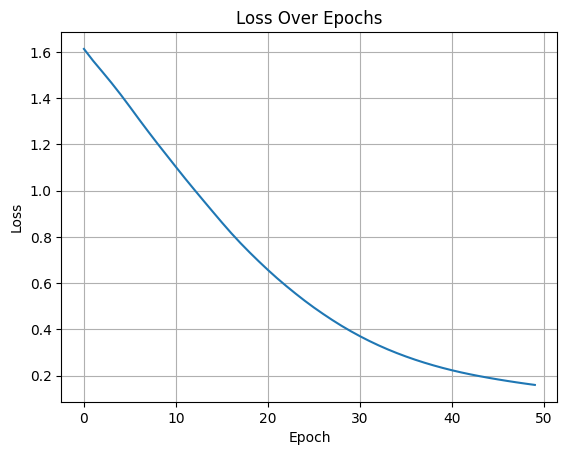

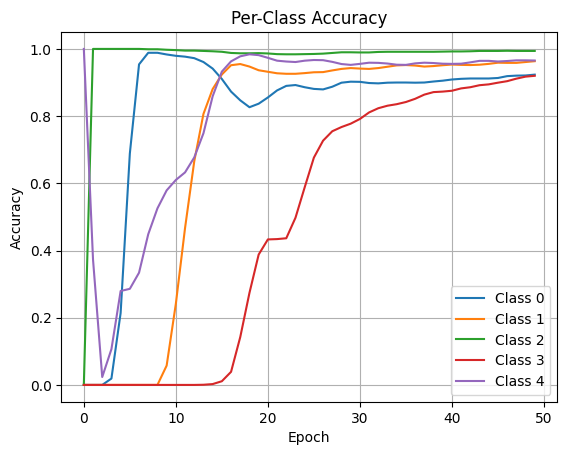

In [39]:
model.plot_loss()
model.plot_class_accuracy()

# Hyperparameter Tuning

In [40]:
def validate_and_return(model, data, labels):
    model.eval()
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.long)

    with torch.no_grad():
        y_pred = model(data)
        loss = model.loss_fn(y_pred, labels)
        preds = y_pred.argmax(dim=1)
        accuracy = (preds == labels).float().mean().item()
        class_acc = model.per_class_accuracy(labels, preds, model.linear[-1].out_features)

    model.train()
    return accuracy, loss.item(), class_acc

def hyperparameter_search(train_data, train_labels, val_data, val_labels, save_path="tuning_results.csv"):
    hidden_layer_options = [1, 3, 5]
    learning_rate_options = [1e-3, 1e-4]
    epoch_options = [50, 100]

    input_size = 2500
    output_size = 5

    results = []

    for num_layers, lr, epochs in product(hidden_layer_options, learning_rate_options, epoch_options):
        print(f"\nRunning config → Hidden Layers: {num_layers}, Learning Rate: {lr}, Epochs: {epochs}")

        model = Network(
            input_size=input_size,
            num_hidden_layer=num_layers,
            hidden_size=128,
            output_size=output_size,
            lr=lr
        )

        start_time = time.time()
        train(model, train_data, train_labels, epochs=epochs)
        end_time = time.time()

        elapsed_time = end_time - start_time
        val_acc, val_loss, class_acc = validate_and_return(model, val_data, val_labels)

        results.append({
            "hidden_layers": num_layers,
            "learning_rate": lr,
            "epochs": epochs,
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "train_time_sec": elapsed_time,
            "class_0": class_acc[0],
            "class_1": class_acc[1],
            "class_2": class_acc[2],
            "class_3": class_acc[3],
            "class_4": class_acc[4],
        })

    # Save to CSV
    df = pd.DataFrame(results)
    df.to_csv(save_path, index=False)
    print(f"\nAll results saved to {save_path}")

Refer to tuning_results.csv for detailed output of tuning

In [41]:
results = hyperparameter_search(train_images, train_labels_, val_images, val_labels_)


Running config → Hidden Layers: 1, Learning Rate: 0.001, Epochs: 50
Epoch [1/50]: Accuracy: 0.1998,  Loss: 1.6217
Epoch [2/50]: Accuracy: 0.2000,  Loss: 1.5050
Epoch [3/50]: Accuracy: 0.2143,  Loss: 1.4286
Epoch [4/50]: Accuracy: 0.3918,  Loss: 1.3470
Epoch [5/50]: Accuracy: 0.4808,  Loss: 1.2666
Epoch [6/50]: Accuracy: 0.5873,  Loss: 1.1925
Epoch [7/50]: Accuracy: 0.6688,  Loss: 1.1255
Epoch [8/50]: Accuracy: 0.7290,  Loss: 1.0634
Epoch [9/50]: Accuracy: 0.7607,  Loss: 1.0040
Epoch [10/50]: Accuracy: 0.7834,  Loss: 0.9488
Epoch [11/50]: Accuracy: 0.7963,  Loss: 0.8982
Epoch [12/50]: Accuracy: 0.8094,  Loss: 0.8519
Epoch [13/50]: Accuracy: 0.8217,  Loss: 0.8091
Epoch [14/50]: Accuracy: 0.8391,  Loss: 0.7690
Epoch [15/50]: Accuracy: 0.8548,  Loss: 0.7318
Epoch [16/50]: Accuracy: 0.8682,  Loss: 0.6976
Epoch [17/50]: Accuracy: 0.8794,  Loss: 0.6658
Epoch [18/50]: Accuracy: 0.8864,  Loss: 0.6360
Epoch [19/50]: Accuracy: 0.8930,  Loss: 0.6081
Epoch [20/50]: Accuracy: 0.8973,  Loss: 0.5819
